# KNN House Price Prediction

This notebook builds a KNN regression pipeline to predict `Tran_Pri` from the housing transaction dataset. The workflow is organized into data loading, exploratory analysis, time-aware splitting, feature engineering, model tuning, evaluation, and visual diagnostics.

## 1. Import Libraries

This cell imports the Python packages used for data handling, plotting, preprocessing, model selection, evaluation, and saving the trained pipeline.

In [4]:
# Import libraries for data handling, visualization, preprocessing,
# model tuning, evaluation, and model persistence.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings('ignore')

# Set a consistent plotting style for the notebook.
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Load the Training Data

This cell reads `TRAIN.csv`, prints the dataset shape, and previews the first few rows so we can confirm that the file loaded correctly.

In [5]:
# Load the training dataset from the current folder.
# Preview the size and first few rows to confirm the data loaded correctly.
BASE_DIR = Path.cwd()
TRAIN_PATH = BASE_DIR.parent / "data" / "TRAIN.csv"
TEST_PATH = BASE_DIR.parent / "data" / "TEST.csv"
OUTPUT_DIR = BASE_DIR / "outputs"

print("Base directory:", BASE_DIR)
print("Training file exists:", TRAIN_PATH.exists(), TRAIN_PATH)
print("Test file exists:", TEST_PATH.exists(), TEST_PATH)

df = pd.read_csv(TRAIN_PATH)
print("Data shape:", df.shape)
df.head()


Base directory: d:\MACHINE LEARNING\knn_catboost\knn
Training file exists: True d:\MACHINE LEARNING\knn_catboost\data\TRAIN.csv
Test file exists: True d:\MACHINE LEARNING\knn_catboost\data\TEST.csv
Data shape: (165808, 23)


,City,Reg,Dist,Neigh,Tran_Dt,Tran_Day,Tran_Pri,Layout,Prop_Flo,Tot_Flo,...,Build_Yr,ReNov,Build_Str,EA_Ratio,Lift,Prop_Type,Build_Pur,Total_Rooms,Build_Yr_Filled,Elevator_Density
0,Hangzhou,Xiacheng,Zhaohui,Zhaohuiqiqu,2012.11.22,64,640,1Room1Livingroom1Kitchen1Bathroom,Upper floor,7.0,...,1985.0,Others,Brick hybrid,1E2A,No,Commercial property,Normal residence,2,1985.0,0.500000
1,Hangzhou,Xiacheng,Zhaohui,Zhaohuiqiqu,2012.11.26,64,1080,2Room1Livingroom1Kitchen1Bathroom,Middle floor,7.0,...,1986.0,Others,Brick hybrid,1E3A,No,Commercial property,Normal residence,3,1986.0,0.333333
2,Hangzhou,Xihu,Cuiyuan,Fenghuafudi,2012.12.07,1,1240,1Room0Livingroom1Kitchen1Bathroom,Middle floor,25.0,...,2008.0,Others,Steel hybrid,4E14A,Yes,Commercial property,Normal residence,1,2008.0,0.285714
3,Hangzhou,Xiacheng,Liushuiyuan,Pingfanligongyu,2012.12.11,64,2450,3Room1Livingroom1Kitchen1Bathroom,Middle floor,7.0,...,NaN,Others,Steel hybrid,1E2A,No,Commercial property,Normal residence,4,2010.0,0.500000
4,Hangzhou,Gongshu,Hushu,Daoxiangyuannanqu,2012.12.11,64,2000,2Room2Livingroom1Kitchen1Bathroom,Lower floor,7.0,...,1995.0,Others,Brick hybrid,1E2A,No,Commercial property,Normal residence,4,1995.0,0.500000


## 3. Inspect the Dataset Structure

This cell shows column names, data types, and non-null counts. It is useful for spotting categorical fields and columns with missing values before modeling.

In [6]:
# Inspect column names, data types, and non-null counts.
# This helps identify missing values and mixed feature types early.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165808 entries, 0 to 165807
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   City              165808 non-null  object 
 1   Reg               165808 non-null  object 
 2   Dist              165808 non-null  object 
 3   Neigh             165808 non-null  object 
 4   Tran_Dt           165808 non-null  object 
 5   Tran_Day          165808 non-null  int64  
 6   Tran_Pri          165808 non-null  int64  
 7   Layout            165808 non-null  object 
 8   Prop_Flo          165808 non-null  object 
 9   Tot_Flo           165808 non-null  float64
 10  Flo_Area          165808 non-null  float64
 11  Build_Type        165808 non-null  object 
 12  Orient            165808 non-null  object 
 13  Build_Yr          105708 non-null  float64
 14  ReNov             165808 non-null  object 
 15  Build_Str         165808 non-null  object 
 16  EA_Ratio          16

## 4. Summary Statistics

This cell generates descriptive statistics for both numeric and categorical columns to understand value ranges, dominant categories, and general data spread.

In [7]:
# Generate summary statistics for both numeric and categorical columns.
# This gives a quick sense of ranges, frequencies, and overall spread.
df.describe(include='all')


,City,Reg,Dist,Neigh,Tran_Dt,Tran_Day,Tran_Pri,Layout,Prop_Flo,Tot_Flo,...,Build_Yr,ReNov,Build_Str,EA_Ratio,Lift,Prop_Type,Build_Pur,Total_Rooms,Build_Yr_Filled,Elevator_Density
count,165808,165808,165808,165808,165808,165808.000000,165808.000000,165808,165808,165808.000000,...,105708.000000,165808,165808,165808,165808,165808,165808,165808.000000,165808.000000,165808.000000
unique,9,64,399,12296,2743,NaN,NaN,319,4,NaN,...,NaN,4,7,480,2,8,7,NaN,NaN,NaN
top,Hangzhou,Yuhang,Xianlin,Zhuhaishuiyun,2020.03.31,NaN,NaN,2Room1Livingroom1Kitchen1Bathroom,Middle floor,NaN,...,NaN,Fully-furnished,Steel hybrid,1E2A,Yes,Commercial property,Normal residence,NaN,NaN,NaN
freq,97954,26043,5536,485,450,NaN,NaN,32070,65271,NaN,...,NaN,68714,112158,53648,108375,164783,158267,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,114.125271,2322.409238,NaN,NaN,15.145355,...,2007.742233,NaN,NaN,NaN,NaN,NaN,NaN,4.128486,2008.560600,0.528145
std,NaN,NaN,NaN,NaN,NaN,138.693985,1628.105281,NaN,NaN,9.361442,...,8.543141,NaN,NaN,NaN,NaN,NaN,NaN,1.272729,6.907118,0.517073
min,NaN,NaN,NaN,NaN,NaN,1.000000,10.000000,NaN,NaN,1.000000,...,1900.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1900.000000,0.006897
25%,NaN,NaN,NaN,NaN,NaN,25.000000,1350.000000,NaN,NaN,7.000000,...,2002.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,2007.000000,0.333333
50%,NaN,NaN,NaN,NaN,NaN,64.000000,1990.000000,NaN,NaN,13.000000,...,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,2010.000000,0.500000
75%,NaN,NaN,NaN,NaN,NaN,150.000000,2810.000000,NaN,NaN,22.000000,...,2015.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,2012.000000,0.500000


## 5. Missing-Value Check

This cell counts missing values in each column. The result guides later imputation and feature preparation steps.

In [8]:
# Count missing values by column so we know where imputation is needed.
df.isnull().sum()


City                    0
Reg                     0
Dist                    0
Neigh                   0
Tran_Dt                 0
Tran_Day                0
Tran_Pri                0
Layout                  0
Prop_Flo                0
Tot_Flo                 0
Flo_Area                0
Build_Type              0
Orient                  0
Build_Yr            60100
ReNov                   0
Build_Str               0
EA_Ratio                0
Lift                    0
Prop_Type               0
Build_Pur               0
Total_Rooms             0
Build_Yr_Filled         0
Elevator_Density        0
dtype: int64

## 6. Target Distribution

This cell plots the distribution of `Tran_Pri` so we can inspect skewness, spread, and possible outliers in the target variable.

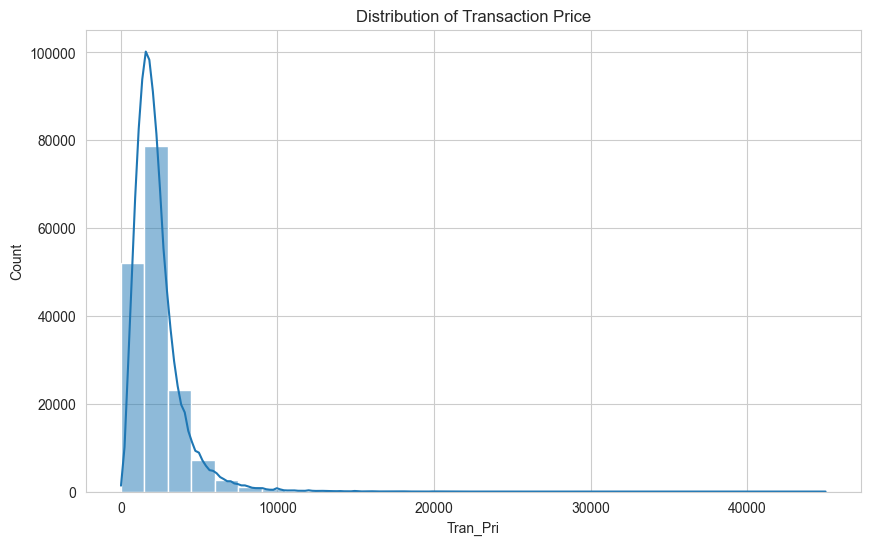

In [9]:
# Visualize the target distribution to understand skewness,
# spread, and potential outliers in transaction price.
plt.figure()
sns.histplot(df['Tran_Pri'], bins=30, kde=True)
plt.title('Distribution of Transaction Price')
plt.show()


## 7. Parse the Transaction Date

This cell converts the `Tran_Dt` string into a proper datetime field. That parsed date is then used for chronological splitting and time-based feature creation.

In [10]:
# Inspect a few raw date strings, then parse the transaction date.
# The parsed datetime column is used for time-aware splitting later.
print("Unique Tran_Dt sample:", df['Tran_Dt'].unique()[:10])
df['Tran_Dt_parsed'] = pd.to_datetime(df['Tran_Dt'], format='%Y.%m.%d', errors='coerce')
print("Date range:", df['Tran_Dt_parsed'].min(), "to", df['Tran_Dt_parsed'].max())


Unique Tran_Dt sample: ['2012.11.22' '2012.11.26' '2012.12.07' '2012.12.11' '2012.12.14'
 '2012.12.23' '2012.12.26' '2012.12.27' '2012.12.31' '2013.01.08']
Date range: 2012-11-22 00:00:00 to 2021-06-30 00:00:00


## 8. Chronological Train-Holdout Split

This cell sorts the records by transaction date and creates a time-based split. The earlier portion is used for training and the later portion is used as a holdout set to better reflect future prediction performance.

In [11]:
# Sort records chronologically to avoid training on future observations.
# Use the earliest 85% for training and the latest 15% as holdout data.
df = df.sort_values('Tran_Dt_parsed').reset_index(drop=True)

split_idx = int(0.85 * len(df))
train_df = df.iloc[:split_idx].copy()
holdout_df = df.iloc[split_idx:].copy()

print(
    f"Train set: {train_df.shape[0]} samples "
    f"({train_df['Tran_Dt_parsed'].min()} to {train_df['Tran_Dt_parsed'].max()})"
)
print(
    f"Holdout set: {holdout_df.shape[0]} samples "
    f"({holdout_df['Tran_Dt_parsed'].min()} to {holdout_df['Tran_Dt_parsed'].max()})"
)


Train set: 140936 samples (2012-11-22 00:00:00 to 2021-03-19 00:00:00)
Holdout set: 24872 samples (2021-03-19 00:00:00 to 2021-06-30 00:00:00)


## 9. Feature Engineering

This cell defines and applies a reusable feature engineering function. It creates date- and property-based features, extracts counts from the layout text, and removes columns that are not retained in this KNN workflow.

In [12]:
# Apply the same feature engineering logic to training, holdout, and test data.
# The goal is to create a compact set of model-ready variables for KNN.
def feature_engineering(data):
    """Create reusable engineered features from the raw transaction data."""

    df_fe = data.copy()

    # Parse the transaction date again inside the function so it also works on TEST.csv.
    df_fe['Tran_Dt_parsed'] = pd.to_datetime(df_fe['Tran_Dt'], format='%Y.%m.%d', errors='coerce')

    # Extract basic calendar features from the transaction date.
    df_fe['Tran_Year'] = df_fe['Tran_Dt_parsed'].dt.year
    df_fe['Tran_Month'] = df_fe['Tran_Dt_parsed'].dt.month

    # Estimate property age at the time of transaction.
    df_fe['Build_Age'] = df_fe['Tran_Year'] - df_fe['Build_Yr_Filled']

    # Convert floor-position text into an ordinal numeric feature.
    floor_mapping = {'Upper floor': 3, 'Middle floor': 2, 'Lower floor': 1}
    df_fe['Prop_Flo_Num'] = df_fe['Prop_Flo'].map(floor_mapping).fillna(2)

    # Extract room counts from the text layout description.
    df_fe['Rooms_From_Layout'] = df_fe['Layout'].str.extract(r'(\d+)Room').astype(float)
    df_fe['Livingrooms_From_Layout'] = df_fe['Layout'].str.extract(r'(\d+)Livingroom').astype(float)
    df_fe['Kitchens_From_Layout'] = df_fe['Layout'].str.extract(r'(\d+)Kitchen').astype(float)
    df_fe['Bathrooms_From_Layout'] = df_fe['Layout'].str.extract(r'(\d+)Bathroom').astype(float)

    # Drop raw columns that are not kept directly in this KNN feature set.
    df_fe = df_fe.drop(
        columns=[
            'Tran_Dt', 'Tran_Dt_parsed', 'Tran_Day', 'Build_Yr', 'Layout',
            'Prop_Flo', 'City', 'Neigh', 'Tot_Flo', 'Build_Type', 'EA_Ratio',
            'Build_Pur', 'Total_Rooms', 'Build_Yr_Filled', 'Elevator_Density',
            'Tran_Year', 'Tran_Month'
        ],
        errors='ignore'
    )

    return df_fe

# Apply feature engineering consistently to both chronological splits.
train_fe = feature_engineering(train_df)
holdout_fe = feature_engineering(holdout_df)

# Separate features and target for model training and evaluation.
target = 'Tran_Pri'
X_train = train_fe.drop(columns=[target])
y_train = train_fe[target]
X_holdout = holdout_fe.drop(columns=[target])
y_holdout = holdout_fe[target]

print("Training features shape:", X_train.shape)
print("Holdout features shape:", X_holdout.shape)


Training features shape: (140936, 14)
Holdout features shape: (24872, 14)


## 10. Preprocessing and KNN Model Tuning

This cell separates numeric and categorical features, builds preprocessing pipelines, and tunes a `KNeighborsRegressor` with `TimeSeriesSplit` and `GridSearchCV`.

In [ ]:
# Identify numeric and categorical feature groups for preprocessing.
numeric_features = X_holdout.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_holdout.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Numeric columns are median-imputed and standardized for distance-based KNN.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical columns are filled and one-hot encoded so KNN can use them.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine the preprocessing steps into a single column-wise transformer.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Build a full modeling pipeline: preprocessing first, then KNN regression.
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor())
])

# Use time-series cross-validation because the data was ordered by date.
tscv = TimeSeriesSplit(n_splits=5)

# Search over a small grid of key KNN hyperparameters.
param_grid = {
    'regressor__n_neighbors': [3, 5, 7, 9, 11, 15],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__metric': ['euclidean', 'manhattan']
}

# Optimize the model using negative MAE so lower absolute error is preferred.
grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score (negative MAE):", grid_search.best_score_)

best_model = grid_search.best_estimator_


Numeric features: ['Flo_Area', 'Build_Age', 'Prop_Flo_Num', 'Rooms_From_Layout', 'Livingrooms_From_Layout', 'Kitchens_From_Layout', 'Bathrooms_From_Layout']
Categorical features: ['Reg', 'Dist', 'Orient', 'ReNov', 'Build_Str', 'Lift', 'Prop_Type']
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'regressor__metric': 'manhattan', 'regressor__n_neighbors': 7, 'regressor__weights': 'distance'}
Best CV score (negative MAE): -585.0262213073798


## 11. Holdout Evaluation and Model Saving

This cell scores the tuned model on the chronological holdout set, reports MAE, RMSE, and R-squared, and saves the best fitted pipeline to disk.

In [ ]:
# Predict on the holdout set and compute the main regression metrics.
# Save the best fitted pipeline so the same model can be reused later.
y_pred_holdout = best_model.predict(X_holdout)

mae_holdout = mean_absolute_error(y_holdout, y_pred_holdout)
rmse_holdout = np.sqrt(mean_squared_error(y_holdout, y_pred_holdout))
r2_holdout = r2_score(y_holdout, y_pred_holdout)

print("Holdout Set Performance:")
print(f"MAE : {mae_holdout:.2f}")
print(f"RMSE: {rmse_holdout:.2f}")
print(f"R^2 : {r2_holdout:.4f}")

joblib.dump(best_model, OUTPUT_DIR / 'knn_price_model.joblib')
print("Model saved as 'knn_price_model.joblib'")


Holdout Set Performance:
MAE : 566.11
RMSE: 1021.99
R²  : 0.6678
Model saved as 'knn_price_model.joblib'


## 12. Score the External Test Set

This cell loads `TEST.csv`, applies the same feature engineering steps, generates predictions with the saved model, and calculates evaluation metrics if true target values are present.

In [12]:
# Load the external test data and apply the same feature engineering steps.
# Then generate predictions with the saved KNN pipeline.
new_test = pd.read_csv(TEST_PATH)
print("New test data shape:", new_test.shape)

new_test_fe = feature_engineering(new_test)
new_test_fe = new_test_fe.drop(columns=['Tran_Pri'], errors='ignore')
print("Engineered test data shape:", new_test_fe.shape)

loaded_model = joblib.load(OUTPUT_DIR / 'knn_price_model.joblib')
new_test['Predicted_Price'] = loaded_model.predict(new_test_fe)

# If the test file includes the true target, calculate final metrics as well.
if 'Tran_Pri' in new_test.columns:
    y_new_true = new_test['Tran_Pri']
    y_new_pred = new_test['Predicted_Price']
    mae_new = mean_absolute_error(y_new_true, y_new_pred)
    rmse_new = np.sqrt(mean_squared_error(y_new_true, y_new_pred))
    r2_new = r2_score(y_new_true, y_new_pred)
    print("\nNew Test Set Performance:")
    print(f"MAE : {mae_new:.2f}")
    print(f"RMSE: {rmse_new:.2f}")
    print(f"R^2 : {r2_new:.4f}")
else:
    mae_new = rmse_new = r2_new = None
    print("No target column found; only predictions were generated.")

# Save the full test file with predictions appended.
new_test.to_csv(OUTPUT_DIR / 'new_test_with_predictions.csv', index=False)
print("Predictions saved to 'new_test_with_predictions.csv'")

New test data shape: (62733, 23)
Engineered test data shape: (62733, 14)

New Test Set Performance:
MAE : 608.71
RMSE: 1162.79
R^2 : 0.6404
Predictions saved to 'new_test_with_predictions.csv'


## 13. Compare Holdout and Test Metrics

This cell creates a side-by-side bar chart for MAE, RMSE, and R-squared so performance can be compared across the holdout and test datasets.

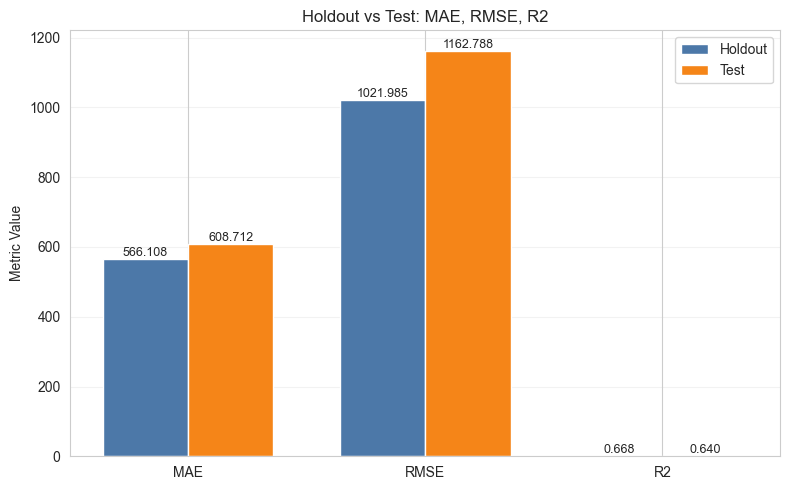

In [28]:
# Plot holdout and test metrics side by side for quick comparison.
# This highlights whether the model stays stable on later unseen data.
import matplotlib.pyplot as plt
import numpy as np

metric_names = ["MAE", "RMSE", "R2"]
holdout_vals = [mae_holdout, rmse_holdout, r2_holdout]
test_vals = [mae_new, rmse_new, r2_new]

x = np.arange(len(metric_names))
width = 0.36

plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width / 2, holdout_vals, width, label="Holdout", color="#4C78A8")
bars2 = plt.bar(x + width / 2, test_vals, width, label="Test", color="#F58518")

plt.xticks(x, metric_names)
plt.ylabel("Metric Value")
plt.title("Holdout vs Test: MAE, RMSE, R2")
plt.legend()
plt.grid(axis="y", alpha=0.25)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()


## 14. Holdout Actual vs Predicted Plot

This scatter plot compares actual and predicted prices on the holdout set. Points closer to the diagonal line indicate better prediction quality.

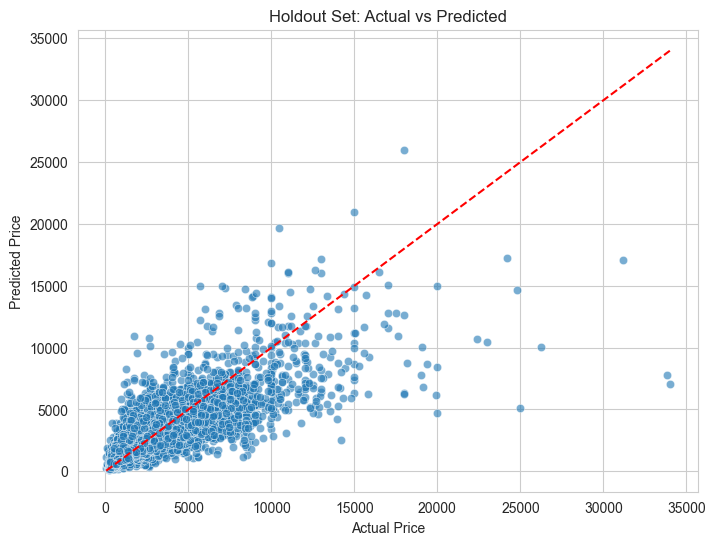

In [29]:
# Plot actual versus predicted holdout prices.
# Better predictions will cluster closer to the red diagonal reference line.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_holdout, y=y_pred_holdout, alpha=0.6)
plt.plot([y_holdout.min(), y_holdout.max()], [y_holdout.min(), y_holdout.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Holdout Set: Actual vs Predicted')
plt.show()


## 15. Holdout Residual Distribution

This cell visualizes the distribution of residuals on the holdout set. It helps show whether prediction errors are centered and how widely they spread.

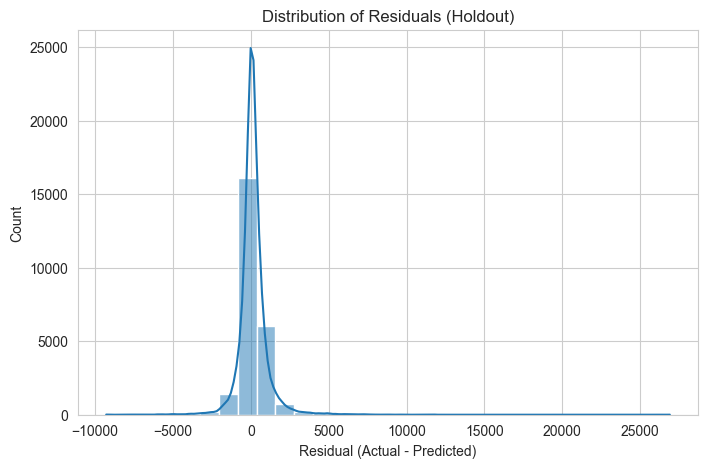

In [30]:
# Plot the residual distribution on the holdout set.
# Residuals are actual price minus predicted price.
residuals = y_holdout - y_pred_holdout
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel('Residual (Actual - Predicted)')
plt.title('Distribution of Residuals (Holdout)')
plt.show()


## 16. Test-Set Diagnostic Plots

If `TEST.csv` includes actual prices, this cell produces the same diagnostic plots for the external test set to check generalization on later data.

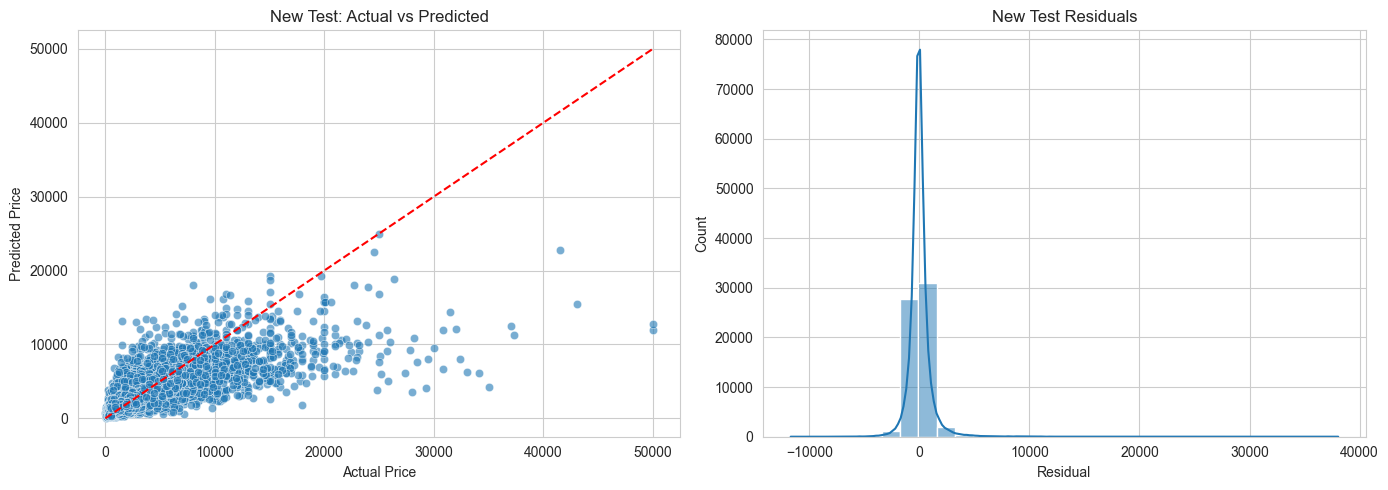

In [31]:
# If the test file contains actual prices, create the same two diagnostics.
# This helps compare generalization quality on external data.
if 'Tran_Pri' in new_test.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot for actual versus predicted test prices.
    sns.scatterplot(x=y_new_true, y=y_new_pred, ax=axes[0], alpha=0.6)
    axes[0].plot([y_new_true.min(), y_new_true.max()], [y_new_true.min(), y_new_true.max()], 'r--')
    axes[0].set_xlabel('Actual Price')
    axes[0].set_ylabel('Predicted Price')
    axes[0].set_title('New Test: Actual vs Predicted')

    # Residual histogram for the test set.
    residuals_new = y_new_true - y_new_pred
    sns.histplot(residuals_new, bins=30, kde=True, ax=axes[1])
    axes[1].set_xlabel('Residual')
    axes[1].set_title('New Test Residuals')

    plt.tight_layout()
    plt.show()


## 17. Correlation Check for Numeric Features

This cell computes and plots linear correlations between engineered numeric features and `Tran_Pri`. It is a simple feature relevance check, not a causal analysis.

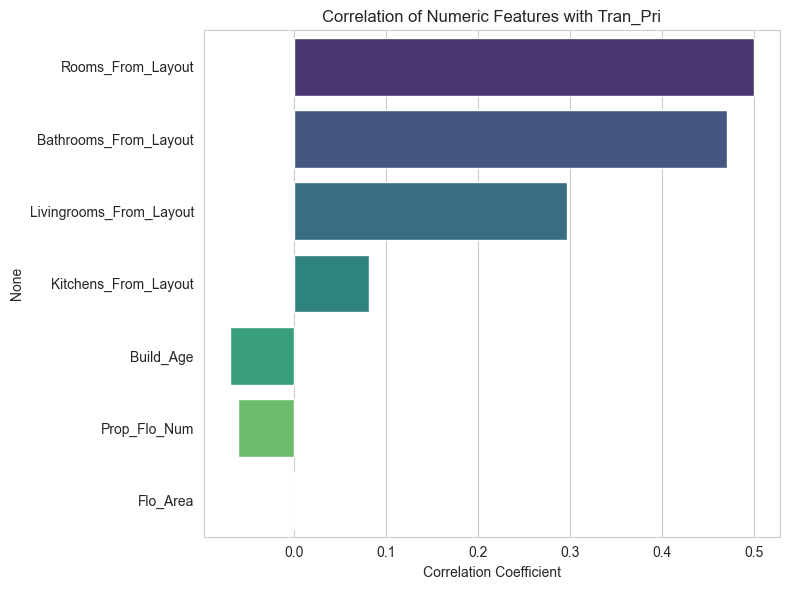

In [32]:
# Compute simple linear correlations between numeric engineered features
# and the transaction price target.
train_corr = train_fe.corr(numeric_only=True)[target].drop(target).sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=train_corr.values, y=train_corr.index, palette='viridis')
plt.title('Correlation of Numeric Features with Tran_Pri')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()


## 18. Mutual Information for Categorical Features

This cell ranks categorical features using mutual information after ordinal encoding. Mutual information can capture non-linear relationships with the target.

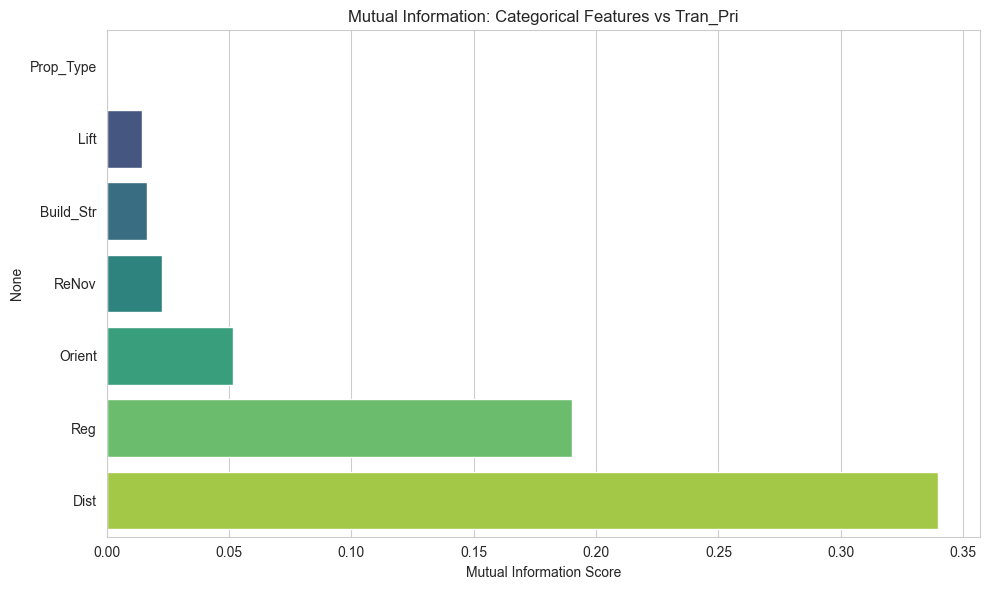

In [36]:
# Estimate mutual information for categorical features.
# This can capture non-linear dependency with the target better than correlation.
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the engineered training target from earlier cells.
y = train_fe[target]

# Select categorical engineered features only.
cat_cols = train_fe.select_dtypes(include=['object', 'category']).columns.tolist()

# Compute mutual information after ordinal encoding each categorical column.
mi_scores = {}
for col in cat_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_col = encoder.fit_transform(train_fe[[col]]).ravel()
    mi = mutual_info_regression(X_col.reshape(-1, 1), y, random_state=42)
    mi_scores[col] = mi[0]

mi_series = pd.Series(mi_scores).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
plt.title('Mutual Information: Categorical Features vs Tran_Pri')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()


## 19. ANOVA F-Statistic for Categorical Features

This cell computes an ANOVA F-statistic for the categorical features after ordinal encoding. It provides another quick feature-ranking view for comparison with mutual information.

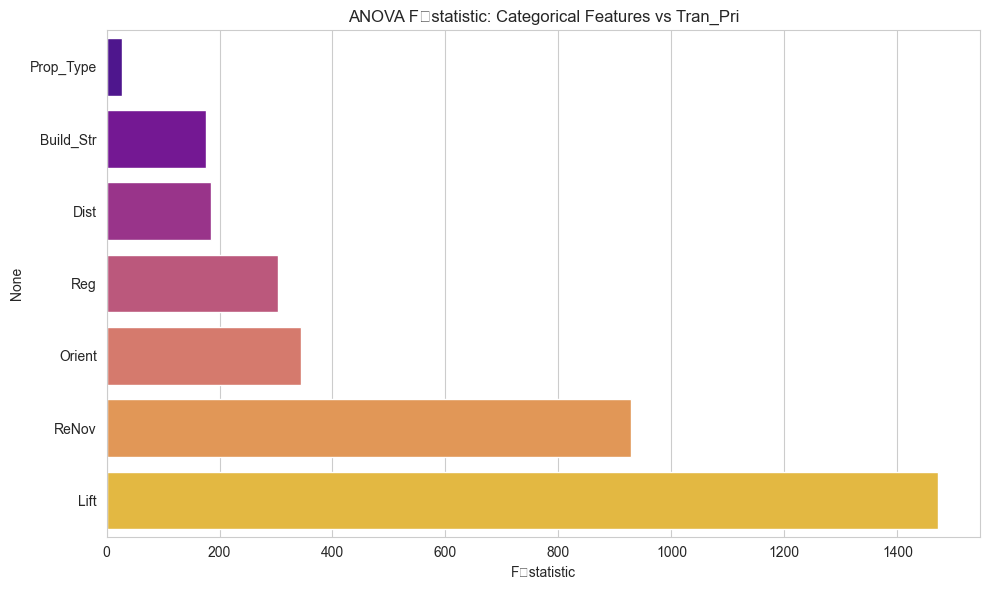

In [37]:
# Compute ANOVA F-statistics for the same categorical features.
# This provides a second feature-ranking view for comparison with mutual information.
from sklearn.feature_selection import f_regression

f_scores = {}
for col in cat_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_col = encoder.fit_transform(train_fe[[col]]).ravel()
    f_stat, _ = f_regression(X_col.reshape(-1, 1), y)
    f_scores[col] = f_stat[0]

f_series = pd.Series(f_scores).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=f_series.values, y=f_series.index, palette='plasma')
plt.title('ANOVA F-statistic: Categorical Features vs Tran_Pri')
plt.xlabel('F-statistic')
plt.tight_layout()
plt.show()
